In [170]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [171]:
!pip install lightgbm xgboost

In [172]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

In [173]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

np.random.seed(42)

NUM_CUSTOMERS = 5000
START_DATE = datetime(2021,1,1)
YEARS = 3

customers = []
transactions = []
bnpl_records = []

categories = [
"groceries","rent","fuel","shopping",
"travel","restaurants","utilities",
"entertainment","medical","education"
]

txn_id = 0

# -----------------------------
# Behaviour profiles
# -----------------------------

profiles = [
"stable",
"bnpl_heavy",
"cc_revolver",
"liquidity_stressed",
"cash_advance_user",
"external_support_user"
]

profile_probs = [0.25,0.15,0.20,0.20,0.10,0.10]

# -----------------------------
# Create customers
# -----------------------------

for cid in range(NUM_CUSTOMERS):

    income = np.random.randint(30000,200000)

    profile = np.random.choice(profiles,p=profile_probs)

    customers.append({
        "customer_id":cid,
        "age":np.random.randint(21,65),
        "monthly_income":income,
        "employment_type":np.random.choice(["salaried","self_employed"]),
        "city_tier":np.random.choice(["tier1","tier2","tier3"]),
        "credit_cards":np.random.randint(1,4),
        "credit_limit_total":np.random.randint(50000,400000),
        "profile":profile
    })

customers = pd.DataFrame(customers)

# -----------------------------
# Generate transactions
# -----------------------------

for _,cust in customers.iterrows():

    balance = cust.monthly_income * 2
    profile = cust.profile

    for day in range(365*YEARS):

        date = START_DATE + timedelta(days=day)

        # salary
        if date.day == 1:

            balance += cust.monthly_income

            transactions.append({
                "txn_id":txn_id,
                "customer_id":cust.customer_id,
                "date":date,
                "channel":"income",
                "amount":cust.monthly_income,
                "category":"salary",
                "balance_after":balance
            })

            txn_id += 1

        # spending probability
        spend_prob = 0.30

        if profile in ["bnpl_heavy","liquidity_stressed"]:
            spend_prob = 0.45

        if np.random.rand() < spend_prob:

            amount = np.random.randint(100,6000)

            channel_probs = [0.6,0.3,0.1]

            if profile == "bnpl_heavy":
                channel_probs = [0.4,0.3,0.3]

            if profile == "cc_revolver":
                channel_probs = [0.4,0.5,0.1]

            channel = np.random.choice(
                ["debit","credit_card","bnpl"],
                p=channel_probs
            )

            balance -= amount

            transactions.append({
                "txn_id":txn_id,
                "customer_id":cust.customer_id,
                "date":date,
                "channel":channel,
                "amount":amount,
                "category":random.choice(categories),
                "balance_after":balance
            })

            txn_id += 1

        # cash advance behaviour
        if profile == "cash_advance_user" and np.random.rand() < 0.05:

            amount = np.random.randint(2000,10000)

            transactions.append({
                "txn_id":txn_id,
                "customer_id":cust.customer_id,
                "date":date,
                "channel":"credit_cash",
                "amount":amount,
                "category":"cash_advance",
                "balance_after":balance + amount
            })

            txn_id += 1

        # external support
        if profile == "external_support_user" and np.random.rand() < 0.04:

            amount = np.random.randint(3000,15000)

            transactions.append({
                "txn_id":txn_id,
                "customer_id":cust.customer_id,
                "date":date,
                "channel":"external_support",
                "amount":amount,
                "category":"family_transfer",
                "balance_after":balance + amount
            })

            txn_id += 1

transactions = pd.DataFrame(transactions)

# -----------------------------
# BNPL Installments
# -----------------------------

bnpl = transactions[transactions.channel=="bnpl"]

for _,txn in bnpl.iterrows():

    installments = np.random.choice([3,6])

    installment_amt = txn.amount/installments

    for i in range(installments):

        paid = np.random.choice([1,0],p=[0.9,0.1])

        bnpl_records.append({
            "customer_id":txn.customer_id,
            "installment_amt":installment_amt,
            "paid":paid
        })

bnpl_records = pd.DataFrame(bnpl_records)

# -----------------------------
# Save datasets
# -----------------------------

customers.to_csv("customers.csv",index=False)
transactions.to_csv("transactions.csv",index=False)
bnpl_records.to_csv("bnpl_installments.csv",index=False)

print("Improved synthetic datasets generated.")

Improved synthetic datasets generated.


In [174]:
customers = pd.read_csv("/kaggle/working/customers.csv")

transactions = pd.read_csv("/kaggle/working/transactions.csv")

bnpl_records = pd.read_csv("/kaggle/working/bnpl_installments.csv")

In [175]:
spending = transactions[
    transactions.channel.isin(["debit","credit_card","bnpl","credit_cash"])
]

spending_features = spending.groupby("customer_id").agg({

"amount":["sum","mean","std","max"]

}).reset_index()

spending_features.columns = [
"customer_id",
"total_spend",
"avg_spend",
"spend_volatility",
"max_spend"
]

In [176]:
bnpl_features = bnpl_records.groupby("customer_id").agg({

"installment_amt":["sum","count"],
"paid":lambda x:1-x.mean()

}).reset_index()

bnpl_features.columns = [
"customer_id",
"bnpl_total",
"bnpl_transactions",
"bnpl_default_rate"
]

In [177]:
# cash advance behavior
cash_txn = transactions[transactions.channel=="credit_cash"]

cash_features = cash_txn.groupby("customer_id").agg(
    credit_cash_transactions=("amount","count"),
    credit_cash_total=("amount","sum")
).reset_index()

dataset = dataset.merge(cash_features,on="customer_id",how="left")

dataset.fillna(0,inplace=True)

In [178]:
transfer_txn = transactions[transactions.channel=="transfer_in"]

transfer_features = transfer_txn.groupby("customer_id").agg(
    external_support_transactions=("amount","count"),
    external_support_total=("amount","sum")
).reset_index()

dataset = dataset.merge(transfer_features,on="customer_id",how="left")

dataset.fillna(0,inplace=True)

In [179]:
balance_min = transactions.groupby("customer_id")["balance_after"].min().reset_index()

balance_min.columns=["customer_id","min_balance"]

In [180]:
dataset = customers.merge(spending_features,on="customer_id")

dataset = dataset.merge(bnpl_features,on="customer_id",how="left")

dataset = dataset.merge(balance_min,on="customer_id")

dataset.fillna(0,inplace=True)

In [181]:
# -----------------------------
# CASH ADVANCE FEATURES
# -----------------------------

cash_txn = transactions[transactions["channel"] == "credit_cash"]

cash_features = cash_txn.groupby("customer_id").agg(
    credit_cash_transactions=("amount","count"),
    credit_cash_total=("amount","sum")
).reset_index()

dataset = dataset.merge(cash_features, on="customer_id", how="left")

dataset[["credit_cash_transactions","credit_cash_total"]] = \
dataset[["credit_cash_transactions","credit_cash_total"]].fillna(0)

In [182]:
# -----------------------------
# EXTERNAL SUPPORT FEATURES
# -----------------------------

transfer_txn = transactions[transactions["channel"] == "transfer_in"]

transfer_features = transfer_txn.groupby("customer_id").agg(
    external_support_transactions=("amount","count"),
    external_support_total=("amount","sum")
).reset_index()

dataset = dataset.merge(transfer_features, on="customer_id", how="left")

dataset[["external_support_transactions","external_support_total"]] = \
dataset[["external_support_transactions","external_support_total"]].fillna(0)

In [183]:
dataset["spend_income_ratio"] = dataset["total_spend"]/dataset["monthly_income"]

dataset["bnpl_usage_ratio"] = dataset["bnpl_transactions"]/dataset["total_spend"]

dataset["bnpl_income_ratio"] = dataset["bnpl_total"]/dataset["monthly_income"]

dataset["credit_utilisation"] = dataset["max_spend"]/dataset["credit_limit_total"]

In [184]:
risk_score = (
    dataset["bnpl_income_ratio"] * 0.4 +
    dataset["credit_utilisation"] * 0.3 +
    dataset["spend_income_ratio"] * 0.2 +
    (dataset["min_balance"] < 0).astype(int) * 0.1
)

prob = 1 / (1 + np.exp(-5 * (risk_score - risk_score.mean())))

dataset["default"] = np.random.binomial(1, prob)

In [185]:
dataset["cash_advance_ratio"] = (
    dataset["credit_cash_total"] / dataset["total_spend"]
)

dataset["external_support_ratio"] = (
    dataset["external_support_total"] / dataset["monthly_income"]
)

dataset.fillna(0,inplace=True)

In [186]:
dataset["segment_cash_dependent"] = (
    dataset["cash_advance_ratio"] > 0.25
).astype(int)

dataset["segment_external_support"] = (
    dataset["external_support_ratio"] > 1
).astype(int)

In [187]:
dataset["segment_bnpl_dependent"] = (
    dataset["bnpl_income_ratio"] > 0.35
).astype(int)

In [188]:
dataset["segment_cc_revolver"] = (
    dataset["credit_utilisation"] > 0.75
).astype(int)

In [189]:
dataset["segment_liquidity_stressed"] = (
    dataset["spend_income_ratio"] > 1.2
).astype(int)

In [190]:
dataset["segment_volatile_spender"] = (
    dataset["spend_volatility"] > dataset["avg_spend"]
).astype(int)

In [191]:
dataset["segment_financially_stable"] = (
    (dataset["credit_utilisation"] < 0.4) &
    (dataset["bnpl_income_ratio"] < 0.1)
).astype(int)

In [192]:
dataset["segment_multi_credit_user"] = (
    dataset["credit_cards"] >= 3
).astype(int)

In [193]:
def classify_customer(row):

    if row["bnpl_income_ratio"] > 0.35:
        return "bnpl_dependent"

    elif row["credit_utilisation"] > 0.75:
        return "cc_revolver"

    elif row["spend_income_ratio"] > 1.2:
        return "liquidity_stressed"

    elif row["spend_volatility"] > row["avg_spend"]:
        return "volatile_spender"

    elif row["credit_utilisation"] < 0.4 and row["bnpl_income_ratio"] < 0.1:
        return "financially_stable"

    else:
        return "mixed_behavior"


dataset["behavior_segment"] = dataset.apply(classify_customer,axis=1)

In [194]:
dataset = pd.get_dummies(
dataset,
columns=["employment_type","city_tier","behavior_segment"],
# columns = ["behavior_segment"],
drop_first=True
)

In [195]:
from sklearn.model_selection import train_test_split

features = [
"age",
"monthly_income",
"credit_cards",
"credit_limit_total",
"total_spend",
"avg_spend",
"spend_volatility",
"max_spend",
"bnpl_total",
"bnpl_transactions",
"min_balance",
"bnpl_usage_ratio",
"employment_type_self_employed",
"city_tier_tier2",
"city_tier_tier3",
"credit_cash_total",
"credit_cash_transactions",
"external_support_total",
"external_support_transactions",
"cash_advance_ratio",
"external_support_ratio",
"segment_cash_dependent",
"segment_external_support"
]

X = dataset[features]
y = dataset["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [196]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.calibration import CalibratedClassifierCV
import joblib

# -----------------------------
# Train base XGBoost model
# -----------------------------
base_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

base_model.fit(X_train, y_train)

# -----------------------------
# Calibrate probabilities
# -----------------------------
model = CalibratedClassifierCV(base_model, method="isotonic", cv=5)
model.fit(X_train, y_train)

# -----------------------------
# Predictions
# -----------------------------
preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:,1]

# -----------------------------
# Evaluation
# -----------------------------
print("XGB Accuracy:", accuracy_score(y_test, preds))
print("XGB ROC AUC:", roc_auc_score(y_test, probs))


XGB Accuracy: 0.949
XGB ROC AUC: 0.9914282193143457


In [197]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.calibration import CalibratedClassifierCV
import joblib

# -----------------------------
# Train base model
# -----------------------------
base_model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    class_weight="balanced"
)

base_model.fit(X_train, y_train)

# -----------------------------
# Calibrate probabilities
# -----------------------------
model2 = CalibratedClassifierCV(base_model, method="isotonic", cv=5)
model2.fit(X_train, y_train)

# -----------------------------
# Predictions
# -----------------------------
preds = model2.predict(X_test)
probs = model2.predict_proba(X_test)[:,1]

# -----------------------------
# Evaluation
# -----------------------------
print("Accuracy:", accuracy_score(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probs))

[LightGBM] [Info] Number of positive: 1396, number of negative: 2604
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000322 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2772
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

<Axes: ylabel='feature'>

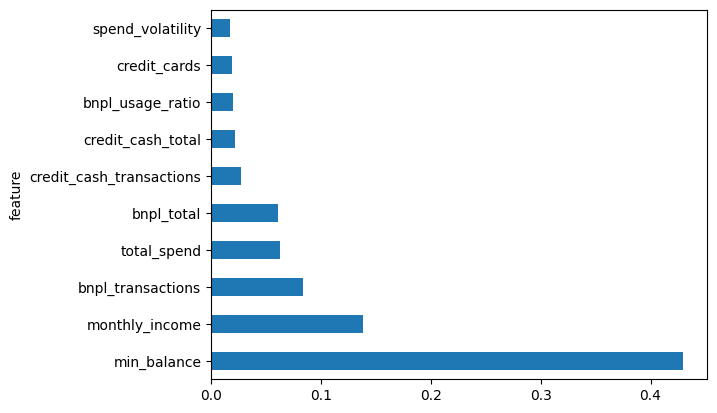

In [199]:
import pandas as pd

# get the underlying trained model
base_model = model.calibrated_classifiers_[0].estimator

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": base_model.feature_importances_
})

importance_df = importance_df.sort_values("importance", ascending=False)

importance_df.head(10).plot(
    x="feature",
    y="importance",
    kind="barh",
    legend=False
)

In [200]:
dataset.to_csv("bnpl_credit_scoring_dataset.csv",index=False)

In [201]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds2)

print(cm)

[[635  16]
 [ 20 329]]


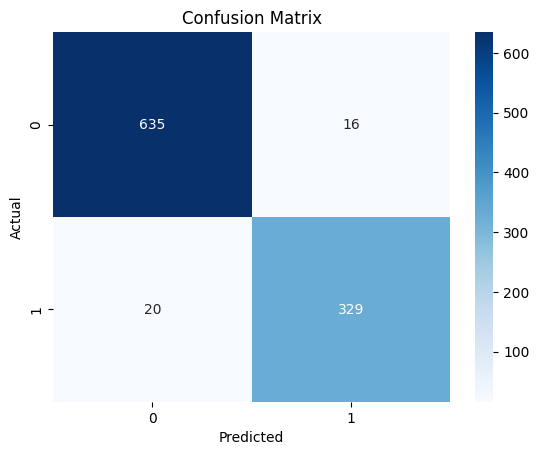

In [202]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [203]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds2))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       651
           1       0.95      0.94      0.95       349

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



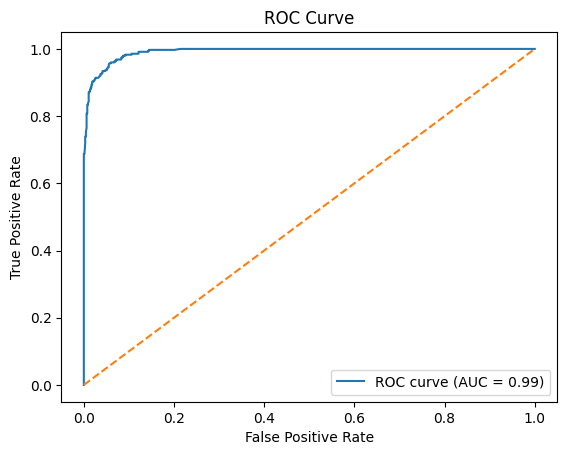

In [204]:
from sklearn.metrics import roc_curve, auc

y_prob = model2.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr,tpr)

plt.plot(fpr,tpr,label="ROC curve (AUC = %0.2f)" % roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [205]:
tp = cm[1,1]

fn = cm[1,0]

default_detection_rate = tp/(tp+fn)

print("Default Detection Rate:", default_detection_rate)

Default Detection Rate: 0.9426934097421203


In [206]:
import joblib

joblib.dump(model2, "model_lgb.pkl")

['model_lgb.pkl']

In [207]:
import joblib

joblib.dump(model2, "modelxgb.pkl")

['modelxgb.pkl']

In [208]:
test_cases = pd.DataFrame([

# 1 SAFE CUSTOMER
{
"age":35,
"monthly_income":90000,
"credit_cards":1,
"credit_limit_total":300000,
"total_spend":20000,
"avg_spend":20000/12,
"spend_volatility":1500,
"max_spend":6000,
"bnpl_total":1000,
"bnpl_transactions":1,
"min_balance":30000,
"bnpl_usage_ratio":1000/20000,
"credit_cash_total":0,
"credit_cash_transactions":0,
"external_support_total":0,
"external_support_transactions":0,
"cash_advance_ratio":0,
"external_support_ratio":0,
"employment_type_self_employed":0,
"city_tier_tier2":0,
"city_tier_tier3":0
},

# 2 MODERATE USER
{
"age":32,
"monthly_income":60000,
"credit_cards":2,
"credit_limit_total":200000,
"total_spend":35000,
"avg_spend":35000/12,
"spend_volatility":3000,
"max_spend":10000,
"bnpl_total":7000,
"bnpl_transactions":4,
"min_balance":8000,
"bnpl_usage_ratio":7000/35000,
"credit_cash_total":2000,
"credit_cash_transactions":1,
"external_support_total":0,
"external_support_transactions":0,
"cash_advance_ratio":2000/35000,
"external_support_ratio":0,

"segment_cash_dependent":0,
"segment_external_support":0,

"employment_type_self_employed":0,
"city_tier_tier2":1,
"city_tier_tier3":0
},

# 3 BNPL DEPENDENT
{
"age":29,
"monthly_income":50000,
"credit_cards":2,
"credit_limit_total":150000,
"total_spend":45000,
"avg_spend":45000/12,
"spend_volatility":4000,
"max_spend":15000,
"bnpl_total":25000,
"bnpl_transactions":10,
"min_balance":2000,
"bnpl_usage_ratio":25000/45000,
"credit_cash_total":5000,
"credit_cash_transactions":3,
"external_support_total":2000,
"external_support_transactions":1,
"cash_advance_ratio":5000/45000,
"external_support_ratio":2000/50000,
"employment_type_self_employed":0,
"city_tier_tier2":0,
"city_tier_tier3":1
},

# 4 CASH DEPENDENT
{
"age":31,
"monthly_income":45000,
"credit_cards":3,
"credit_limit_total":100000,
"total_spend":42000,
"avg_spend":42000/12,
"spend_volatility":5000,
"max_spend":18000,
"bnpl_total":12000,
"bnpl_transactions":6,
"min_balance":-2000,
"bnpl_usage_ratio":12000/42000,
"credit_cash_total":15000,
"credit_cash_transactions":7,
"external_support_total":5000,
"external_support_transactions":2,
"cash_advance_ratio":15000/42000,
"external_support_ratio":5000/45000,
"employment_type_self_employed":1,
"city_tier_tier2":1,
"city_tier_tier3":0
},

# 5 EXTREME RISK
{
"age":27,
"monthly_income":40000,
"credit_cards":4,
"credit_limit_total":80000,
"total_spend":50000,
"avg_spend":50000/12,
"spend_volatility":6000,
"max_spend":20000,
"bnpl_total":35000,
"bnpl_transactions":12,
"min_balance":-5000,
"bnpl_usage_ratio":35000/50000,
"credit_cash_total":20000,
"credit_cash_transactions":10,
"external_support_total":15000,
"external_support_transactions":4,
"cash_advance_ratio":20000/50000,
"external_support_ratio":15000/40000,
"employment_type_self_employed":1,
"city_tier_tier2":1,
"city_tier_tier3":0
},
{
"age":34,
"monthly_income":70000,
"credit_cards":2,
"credit_limit_total":200000,
"total_spend":25000,
"avg_spend":25000/12,
"spend_volatility":2000,
"max_spend":8000,
"bnpl_total":3000,
"bnpl_transactions":2,
"min_balance":15000,
"bnpl_usage_ratio":3000/25000,
"credit_cash_total":0,
"credit_cash_transactions":0,
"external_support_total":0,
"external_support_transactions":0,
"cash_advance_ratio":0,
"external_support_ratio":0,
"employment_type_self_employed":0,
"city_tier_tier2":1,
"city_tier_tier3":0
}

])
test_cases = test_cases[X.columns]
probs = model.predict_proba(test_cases)[:,1]

for i,p in enumerate(probs):
    print(f"Scenario {i+1} default probability:",round(p,3))

Scenario 1 default probability: 0.308
Scenario 2 default probability: 0.597
Scenario 3 default probability: 0.984
Scenario 4 default probability: 0.97
Scenario 5 default probability: 0.97
Scenario 6 default probability: 0.457
